In [ ]:
!pip install torch torchvision torchaudio
!pip install opencv-python matplotlib numpy
!pip install scikit-image

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from skimage.metrics import structural_similarity as ssim

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving final year dataset.zip to final year dataset.zip


In [ ]:
import zipfile
import os

# Unzip the uploaded dataset
zip_file_path = '/content/final year dataset.zip' # Corrected zip file path
output_dir = '/content/' # Extract to content directory

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f'Successfully unzipped {zip_file_path} to {output_dir}')

# List the contents of the extracted directory to verify
print('Contents of /content/:')
!ls -F /content/

Successfully unzipped /content/final year dataset.zip to /content/
Contents of /content/:
'final year dataset'/  'final year dataset.zip'   sample_data/


In [ ]:
import cv2

mri = cv2.imread('/content/final year dataset/mri/img1.png',
                 cv2.IMREAD_GRAYSCALE)

ct = cv2.imread('/content/final year dataset/ct/img1.png',
                cv2.IMREAD_GRAYSCALE)

In [ ]:
print('Contents of /content/final year dataset/mri/ :')
!ls -F '/content/final year dataset/mri/'

print('\nContents of /content/final year dataset/ct/ :')
!ls -F '/content/final year dataset/ct/'

Contents of /content/final year dataset/mri/ :
img1.png

Contents of /content/final year dataset/ct/ :
img1.png


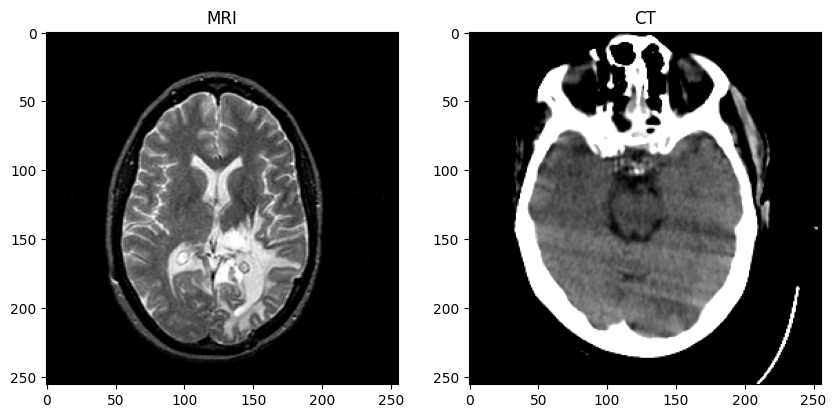

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(mri, cmap='gray')
plt.title("MRI")

plt.subplot(1,2,2)
plt.imshow(ct, cmap='gray')
plt.title("CT")

plt.show()

In [ ]:
mri = cv2.resize(mri, (256,256))
ct = cv2.resize(ct, (256,256))

In [ ]:
print(mri.shape)
print(ct.shape)

(256, 256)
(256, 256)


In [ ]:
mri = mri / 127.5 - 1
ct = ct / 127.5 - 1

In [ ]:
print(mri.min(), mri.max())
print(ct.min(), ct.max())

-1.0 1.0
-1.0 1.0


In [ ]:
import torch

mri = torch.tensor(mri).float().unsqueeze(0)

ct = torch.tensor(ct).float().unsqueeze(0)

In [ ]:
print(mri.shape)
print(ct.shape)

torch.Size([1, 256, 256])
torch.Size([1, 256, 256])


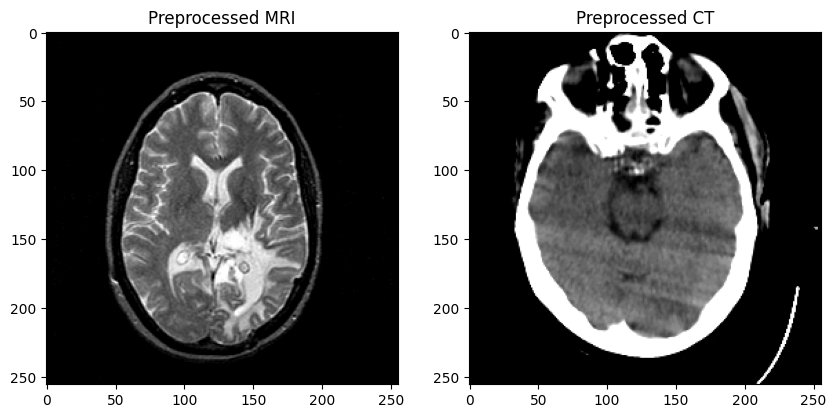

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(mri.squeeze(), cmap='gray')
plt.title("Preprocessed MRI")

plt.subplot(1,2,2)
plt.imshow(ct.squeeze(), cmap='gray')
plt.title("Preprocessed CT")

plt.show()

In [ ]:
import os
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [ ]:
transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((256,256)),

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
class FusionDataset(Dataset):

    def __init__(self, mri_dir, ct_dir, transform=None):

        self.mri_dir = mri_dir
        self.ct_dir = ct_dir
        self.transform = transform

        self.mri_images = sorted(os.listdir(mri_dir))
        self.ct_images = sorted(os.listdir(ct_dir))

    def __len__(self):

        return len(self.mri_images)

    def __getitem__(self, idx):

        mri_path = os.path.join(
            self.mri_dir,
            self.mri_images[idx]
        )

        ct_path = os.path.join(
            self.ct_dir,
            self.ct_images[idx]
        )

        mri = cv2.imread(
            mri_path,
            cv2.IMREAD_GRAYSCALE
        )

        ct = cv2.imread(
            ct_path,
            cv2.IMREAD_GRAYSCALE
        )

        if self.transform:

            mri = self.transform(mri)
            ct = self.transform(ct)

        return mri, ct

In [ ]:
# ==========================================
# STEP 1 — Import Libraries
# ==========================================

import torch
import torch.nn as nn

In [ ]:
# ==========================================
# STEP 2 — Mish Activation
# ==========================================

class Mish(nn.Module):

    def forward(self, x):

        return x * torch.tanh(
            nn.functional.softplus(x)
        )

In [ ]:
# ==========================================
# STEP 3 — Swish Activation
# ==========================================

class Swish(nn.Module):

    def forward(self, x):

        return x * torch.sigmoid(x)

In [ ]:
# ==========================================
# STEP 4 — Encoder Block
# ==========================================

class EncoderBlock(nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels,
                 activation='mish'):

        super().__init__()

        if activation == 'prelu':

            act = nn.PReLU()

        else:

            act = Mish()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1
            ),

            nn.InstanceNorm2d(out_channels),

            act,

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.InstanceNorm2d(out_channels),

            act
        )

    def forward(self, x):

        return self.block(x)

In [ ]:
# ==========================================
# STEP 5 — Residual Block
# ==========================================

class ResidualBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                stride=1,
                padding=1
            ),

            nn.InstanceNorm2d(channels),

            Mish(),

            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                stride=1,
                padding=1
            ),

            nn.InstanceNorm2d(channels),

            Swish()
        )

    def forward(self, x):

        return x + self.block(x)

In [ ]:
# ==========================================
# STEP 6 — Decoder Block
# ==========================================

class DecoderBlock(nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels * 4,
                kernel_size=3,
                stride=1,
                padding=1
            ),

            nn.PixelShuffle(2),

            nn.InstanceNorm2d(out_channels),

            Mish()
        )

    def forward(self, x):

        return self.block(x)

In [ ]:
# ==========================================
# STEP 7 — Generator
# ==========================================

class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        # MRI Encoder

        self.mri_encoder1 = EncoderBlock(
            1, 64, activation='prelu'
        )

        self.mri_encoder2 = EncoderBlock(
            64, 128
        )

        self.mri_encoder3 = EncoderBlock(
            128, 256
        )

        # CT Encoder

        self.ct_encoder1 = EncoderBlock(
            1, 64, activation='prelu'
        )

        self.ct_encoder2 = EncoderBlock(
            64, 128
        )

        self.ct_encoder3 = EncoderBlock(
            128, 256
        )

        # Fusion Conv

        self.fusion = nn.Conv2d(
            512,
            512,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Residual Blocks

        self.res1 = ResidualBlock(512)

        self.res2 = ResidualBlock(512)

        self.res3 = ResidualBlock(512)

        # Decoder

        self.dec1 = DecoderBlock(
            512,
            256
        )

        self.dec2 = DecoderBlock(
            256,
            128
        )

        self.dec3 = DecoderBlock(
            128,
            64
        )

        # Final Output

        self.final = nn.Sequential(

            nn.Conv2d(
                64,
                1,
                kernel_size=3,
                stride=1,
                padding=1
            ),

            nn.Tanh()
        )

    def forward(self, mri, ct):

        # MRI Encoder

        m1 = self.mri_encoder1(mri)

        m2 = self.mri_encoder2(m1)

        m3 = self.mri_encoder3(m2)

        # CT Encoder

        c1 = self.ct_encoder1(ct)

        c2 = self.ct_encoder2(c1)

        c3 = self.ct_encoder3(c2)

        # Concatenate

        fused = torch.cat([m3, c3], dim=1)

        fused = self.fusion(fused)

        # Residual Learning

        fused = self.res1(fused)

        fused = self.res2(fused)

        fused = self.res3(fused)

        # Decoder

        d1 = self.dec1(fused)

        d2 = self.dec2(d1)

        d3 = self.dec3(d2)

        # Output

        out = self.final(d3)

        return out

In [ ]:
# ==========================================
# STEP 8 — Create Generator
# ==========================================

generator = Generator()

print(generator)

Generator(
  (mri_encoder1): EncoderBlock(
    (block): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=1)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (5): PReLU(num_parameters=1)
    )
  )
  (mri_encoder2): EncoderBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): Mish()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (5): Mish()
    )
  )
  (mri_encoder3): EncoderBlock(
    (block): Sequenti

In [ ]:
import os
import cv2

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [ ]:
transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((256,256)),

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
class FusionDataset(Dataset):

    def __init__(self,
                 mri_dir,
                 ct_dir,
                 transform=None):

        self.mri_dir = mri_dir
        self.ct_dir = ct_dir

        self.transform = transform

        self.mri_images = sorted(
            os.listdir(mri_dir)
        )

        self.ct_images = sorted(
            os.listdir(ct_dir)
        )

    def __len__(self):

        return len(self.mri_images)

    def __getitem__(self, idx):

        mri_path = os.path.join(
            self.mri_dir,
            self.mri_images[idx]
        )

        ct_path = os.path.join(
            self.ct_dir,
            self.ct_images[idx]
        )

        mri = cv2.imread(
            mri_path,
            cv2.IMREAD_GRAYSCALE
        )

        ct = cv2.imread(
            ct_path,
            cv2.IMREAD_GRAYSCALE
        )

        if self.transform:

            mri = self.transform(mri)

            ct = self.transform(ct)

        return mri, ct

In [ ]:
dataset = FusionDataset(

    '/content/final year dataset/mri',

    '/content/final year dataset/ct',

    transform=transform
)

In [ ]:
loader = DataLoader(

    dataset,

    batch_size=4,

    shuffle=True
)

In [ ]:
for mri, ct in loader:

    print(mri.shape)

    print(ct.shape)

    break

torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])


In [ ]:
torch.Size([4,1,256,256])

torch.Size([4, 1, 256, 256])

In [ ]:
for mri, ct in loader:

    output = generator(mri, ct)

    print(output.shape)

    break

torch.Size([1, 1, 256, 256])


In [ ]:
# ==========================================
# PATCHGAN DISCRIMINATOR
# ==========================================

class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(
                1,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.LeakyReLU(0.2),

            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.InstanceNorm2d(128),

            nn.LeakyReLU(0.2),

            nn.Conv2d(
                128,
                256,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.InstanceNorm2d(256),

            nn.LeakyReLU(0.2),

            nn.Conv2d(
                256,
                512,
                kernel_size=4,
                stride=1,
                padding=1
            ),

            nn.InstanceNorm2d(512),

            nn.LeakyReLU(0.2),

            nn.Conv2d(
                512,
                1,
                kernel_size=4,
                stride=1,
                padding=1
            )
        )

    def forward(self, x):

        return self.model(x)

In [ ]:
discriminator = Discriminator()

print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (9): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (10): LeakyReLU(negative_slope=0.2)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  )
)


In [ ]:
for mri, ct in loader:

    fake = generator(mri, ct)

    output = discriminator(fake)

    print(output.shape)

    break

torch.Size([1, 1, 30, 30])


In [ ]:
adversarial_loss = nn.BCEWithLogitsLoss()

In [ ]:
l1_loss = nn.L1Loss()

In [ ]:
!pip install pytorch-msssim

In [ ]:
from pytorch_msssim import ssim

In [ ]:
import torch.optim as optim

In [ ]:
g_optimizer = optim.Adam(

    generator.parameters(),

    lr=0.0002,

    betas=(0.5, 0.999)
)

In [ ]:
d_optimizer = optim.Adam(

    discriminator.parameters(),

    lr=0.0002,

    betas=(0.5, 0.999)
)

In [ ]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

generator = generator.to(device)

discriminator = discriminator.to(device)

In [ ]:
print(device)

cpu


In [ ]:
EPOCHS = 100

In [ ]:
# ==========================================
# TRAINING LOOP
# ==========================================

for epoch in range(EPOCHS):

    for mri, ct in loader:

        # ==================================
        # Move to GPU
        # ==================================

        mri = mri.to(device)

        ct = ct.to(device)

        # ==================================
        # Generate Fused Image
        # ==================================

        fake = generator(mri, ct)

        # ==================================
        # REAL & FAKE LABELS
        # ==================================

        real_labels = torch.ones(
            fake.size(0),
            1,
            30,
            30
        ).to(device)

        fake_labels = torch.zeros(
            fake.size(0),
            1,
            30,
            30
        ).to(device)

        # ==================================
        # TRAIN DISCRIMINATOR
        # ==================================

        d_optimizer.zero_grad()

        # Real loss

        real_output = discriminator(ct)

        d_real_loss = adversarial_loss(
            real_output,
            real_labels
        )

        # Fake loss

        fake_output = discriminator(
            fake.detach()
        )

        d_fake_loss = adversarial_loss(
            fake_output,
            fake_labels
        )

        # Total discriminator loss

        d_loss = (
            d_real_loss +
            d_fake_loss
        ) / 2

        d_loss.backward()

        d_optimizer.step()

        # ==================================
        # TRAIN GENERATOR
        # ==================================

        g_optimizer.zero_grad()

        fake_output = discriminator(fake)

        # GAN loss

        g_gan_loss = adversarial_loss(
            fake_output,
            real_labels
        )

        # L1 loss

        g_l1_loss = l1_loss(
            fake,
            (mri + ct) / 2
        )

        # SSIM loss

        g_ssim_loss = 1 - ssim(
            fake,
            (mri + ct) / 2,
            data_range=2,
            size_average=True
        )

        # Total generator loss

        g_loss = (
            g_gan_loss +
            100 * g_l1_loss +
            10 * g_ssim_loss
        )

        g_loss.backward()

        g_optimizer.step()

    # ======================================
    # PRINT LOSSES
    # ======================================

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

Epoch [1/100] D Loss: 0.7000 G Loss: 86.6340
Epoch [2/100] D Loss: 0.7683 G Loss: 70.3105
Epoch [3/100] D Loss: 1.0345 G Loss: 59.3788
Epoch [4/100] D Loss: 0.7510 G Loss: 57.5412
Epoch [5/100] D Loss: 0.6742 G Loss: 48.5488
Epoch [6/100] D Loss: 0.6527 G Loss: 49.9563
Epoch [7/100] D Loss: 0.6365 G Loss: 43.4096
Epoch [8/100] D Loss: 0.6240 G Loss: 42.7303
Epoch [9/100] D Loss: 0.6096 G Loss: 38.8538
Epoch [10/100] D Loss: 0.6169 G Loss: 37.4885
Epoch [11/100] D Loss: 0.6047 G Loss: 36.1577
Epoch [12/100] D Loss: 0.5982 G Loss: 33.3853
Epoch [13/100] D Loss: 0.5833 G Loss: 32.5613
Epoch [14/100] D Loss: 0.5530 G Loss: 30.8125
Epoch [15/100] D Loss: 0.5319 G Loss: 30.3470
Epoch [16/100] D Loss: 0.5322 G Loss: 31.0695
Epoch [17/100] D Loss: 0.5046 G Loss: 30.8266
Epoch [18/100] D Loss: 0.5017 G Loss: 28.7741
Epoch [19/100] D Loss: 0.5179 G Loss: 27.8848
Epoch [20/100] D Loss: 0.5438 G Loss: 25.8173
Epoch [21/100] D Loss: 0.5500 G Loss: 24.6365
Epoch [22/100] D Loss: 0.5632 G Loss: 24.35

In [ ]:
generator.eval()

Generator(
  (mri_encoder1): EncoderBlock(
    (block): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=1)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (5): PReLU(num_parameters=1)
    )
  )
  (mri_encoder2): EncoderBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): Mish()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (5): Mish()
    )
  )
  (mri_encoder3): EncoderBlock(
    (block): Sequenti

In [ ]:
with torch.no_grad():

    for mri, ct in loader:

        mri = mri.to(device)

        ct = ct.to(device)

        fused = generator(mri, ct)

        break

In [ ]:
mri = mri.cpu()

ct = ct.cpu()

fused = fused.cpu()

In [ ]:
mri_img = mri[0][0].numpy()

ct_img = ct[0][0].numpy()

fused_img = fused[0][0].numpy()

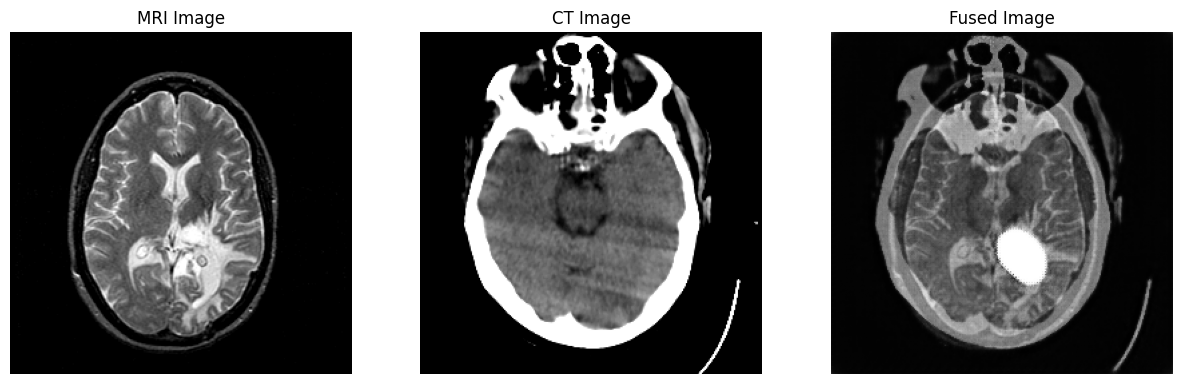

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# MRI

plt.subplot(1,3,1)

plt.imshow(mri_img, cmap='gray')

plt.title("MRI Image")

plt.axis('off')

# CT

plt.subplot(1,3,2)

plt.imshow(ct_img, cmap='gray')

plt.title("CT Image")

plt.axis('off')

# Fused

plt.subplot(1,3,3)

plt.imshow(fused_img, cmap='gray')

plt.title("Fused Image")

plt.axis('off')

plt.show()

In [ ]:
import cv2

save_img = (
    (fused_img + 1) * 127.5
).astype('uint8')

cv2.imwrite(
    'fused_output.png',
    save_img
)

True

In [ ]:
from google.colab import files

files.download('fused_output.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install scikit-image

In [ ]:
from skimage.metrics import (
    structural_similarity,
    peak_signal_noise_ratio,
    mean_squared_error
)

from skimage.measure import shannon_entropy

In [ ]:
mri_eval = (
    (mri_img + 1) * 127.5
).astype('uint8')

ct_eval = (
    (ct_img + 1) * 127.5
).astype('uint8')

fused_eval = (
    (fused_img + 1) * 127.5
).astype('uint8')

In [ ]:
ssim_mri = structural_similarity(
    mri_eval,
    fused_eval
)

In [ ]:
ssim_ct = structural_similarity(
    ct_eval,
    fused_eval
)

In [ ]:
psnr_mri = peak_signal_noise_ratio(
    mri_eval,
    fused_eval
)

psnr_ct = peak_signal_noise_ratio(
    ct_eval,
    fused_eval
)

In [ ]:
mse_mri = mean_squared_error(
    mri_eval,
    fused_eval
)

mse_ct = mean_squared_error(
    ct_eval,
    fused_eval
)

In [ ]:
entropy = shannon_entropy(
    fused_eval
)

In [ ]:
print("========== RESULTS ==========")

print()

print("SSIM MRI-Fused :", ssim_mri)

print("SSIM CT-Fused  :", ssim_ct)

print()

print("PSNR MRI-Fused :", psnr_mri)

print("PSNR CT-Fused  :", psnr_ct)

print()

print("MSE MRI-Fused  :", mse_mri)

print("MSE CT-Fused   :", mse_ct)

print()

print("Entropy        :", entropy)

========== RESULTS ==========

SSIM MRI-Fused : 0.38731195786737727
SSIM CT-Fused  : 0.4165553879392272

PSNR MRI-Fused : 14.808178243892666
PSNR CT-Fused  : 13.52959558286485

MSE MRI-Fused  : 2149.1292572021484
MSE CT-Fused   : 2884.8338317871094

Entropy        : 5.730385070759418


In [ ]:
torch.save(

    generator.state_dict(),

    'generator_model.pth'
)

In [ ]:
torch.save(

    discriminator.state_dict(),

    'discriminator_model.pth'
)

In [ ]:
from google.colab import files

files.download('generator_model.pth')

files.download('discriminator_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
torch.save(
    generator,
    'full_generator.pth'
)

In [ ]:
generator.load_state_dict(
    torch.load('generator_model.pth')
)

generator.eval()

Generator(
  (mri_encoder1): EncoderBlock(
    (block): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=1)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (5): PReLU(num_parameters=1)
    )
  )
  (mri_encoder2): EncoderBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): Mish()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (5): Mish()
    )
  )
  (mri_encoder3): EncoderBlock(
    (block): Sequenti

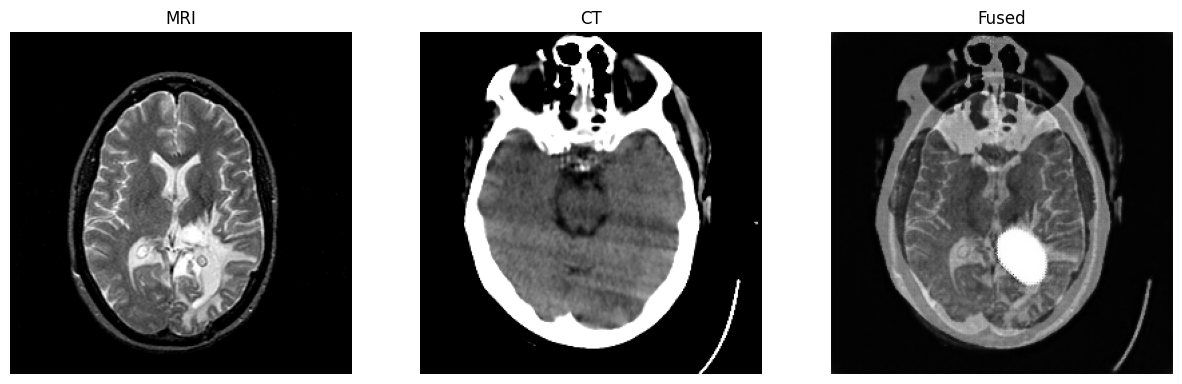

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)

plt.imshow(mri_eval, cmap='gray')

plt.title("MRI")

plt.axis('off')

# ---------------------

plt.subplot(1,3,2)

plt.imshow(ct_eval, cmap='gray')

plt.title("CT")

plt.axis('off')

# ---------------------

plt.subplot(1,3,3)

plt.imshow(fused_eval, cmap='gray')

plt.title("Fused")

plt.axis('off')

plt.savefig(
    'comparison_result.png',
    bbox_inches='tight'
)

plt.show()

In [ ]:
# ==========================================
# CHECK WHETHER FUSED IMAGE IS
# REAL OR FAKE
# ==========================================

generator.eval()

discriminator.eval()

with torch.no_grad():

    for mri, ct in loader:

        # Move to GPU

        mri = mri.to(device)

        ct = ct.to(device)

        # ==================================
        # Generate Fused Image
        # ==================================

        fake = generator(mri, ct)

        # ==================================
        # Discriminator Prediction
        # ==================================

        pred = discriminator(fake)

        # ==================================
        # Convert to Probability
        # ==================================

        prob = torch.sigmoid(pred)

        # ==================================
        # Overall Realness Score
        # ==================================

        score = prob.mean()

        print("Realness Score :", score.item())

        # ==================================
        # CHECK RESULT
        # ==================================

        if score.item() > 0.7:

            print("Fused Image looks REALISTIC")

        elif score.item() > 0.5:

            print("Fused Image is MODERATELY REAL")

        else:

            print("Fused Image looks FAKE")

        break

Realness Score : 0.23322822153568268
Fused Image looks FAKE


In [ ]:
files.download('comparison_result.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>